1. На основе учебного ноутбука проведите финальную подготовку данных. Измените количество сегментирующих классов с `16` на `7`:
  - 0_класс - FLOOR
  - 1_класс - CEILING
  - 2_класс - WALL
  - 3_класс - APERTURE, DOOR, WINDOW
  - 4_класс - COLUMN, RAILINGS, LADDER
  - 5_класс - INVENTORY
  - 6_класс - LAMP, WIRE, BEAM, EXTERNAL, BATTERY,
PEOPLE

2. Изучите внимательно особенности `U-net`, определите в чем принципиальное отличие  `U-net `  и   `simpleUnet` из учебного ноутбука.

3. Доработайте `simpleUnet` с учетом особенностей `U-net `. Обучите модель на 100 эпохах и визуализируйте результат.

**Важно!**

Многие эксперименты могут приводить к переполнению ОЗУ в вашем ноутбуке и сброса кода обучения.

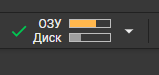

Для предотвращения переполнения ОЗУ может помочь библиотека `gc`. Вставьте строчку `gc.collect()` в цикл ваших экспериментов для сбора и удаления временных данных (кеш).

In [ ]:
import os
import gc
import time
import random

import numpy as np
import matplotlib.pyplot as plt
import gdown

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
DATA_URL = "https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip"
ARCHIVE_NAME = "construction_256x192.zip"

gdown.download(DATA_URL, ARCHIVE_NAME, quiet=False)

!unzip -q -o "construction_256x192.zip"

print("Датасет загружен и распакован")

In [ ]:
IMG_WIDTH = 192
IMG_HEIGHT = 256

TRAIN_DIRECTORY = "train"
VAL_DIRECTORY = "val"

def read_images(folder, section):
    source_dir = os.path.join(folder, section)
    items = []

    t0 = time.time()
    for name in sorted(os.listdir(source_dir)):
        file_path = os.path.join(source_dir, name)
        img = Image.open(file_path).convert("RGB").resize((IMG_HEIGHT, IMG_WIDTH))
        items.append(img)

    print(f"{folder}/{section}: {len(items)} файлов, {round(time.time() - t0, 2)} c")
    return items

train_images = read_images(TRAIN_DIRECTORY, "original")
val_images = read_images(VAL_DIRECTORY, "original")

train_segments = read_images(TRAIN_DIRECTORY, "segment")
val_segments = read_images(VAL_DIRECTORY, "segment")

In [ ]:
FLOOR = (100, 100, 100)
CEILING = (0, 0, 100)
WALL = (0, 100, 0)
COLUMN = (100, 0, 0)
APERTURE = (0, 100, 100)
DOOR = (100, 0, 100)
WINDOW = (100, 100, 0)
EXTERNAL = (200, 200, 200)
RAILINGS = (0, 200, 0)
BATTERY = (200, 0, 0)
PEOPLE = (0, 200, 200)
LADDER = (0, 0, 200)
INVENTORY = (200, 0, 200)
LAMP = (200, 200, 0)
WIRE = (0, 100, 200)
BEAM = (100, 0, 200)

NUM_CLASSES = 7

CLASS_GROUPS = {
    0: [FLOOR],
    1: [CEILING],
    2: [WALL],
    3: [APERTURE, DOOR, WINDOW],
    4: [COLUMN, RAILINGS, LADDER],
    5: [INVENTORY],
    6: [LAMP, WIRE, BEAM, EXTERNAL, BATTERY, PEOPLE],
}

def convert_masks(mask_list):
    result = []

    for img in mask_list:
        arr = np.array(img)
        mask = np.zeros((IMG_WIDTH, IMG_HEIGHT), dtype=np.int64)

        for cls, colors in CLASS_GROUPS.items():
            for color in colors:
                found = np.all(arr == color, axis=-1)
                mask[found] = cls

        result.append(mask)

    return np.asarray(result, dtype=np.int64)

def convert_images(image_list):
    data = np.asarray([np.array(img) for img in image_list], dtype=np.float32) / 255.0
    return np.transpose(data, (0, 3, 1, 2))

x_train = convert_images(train_images)
x_val = convert_images(val_images)

y_train_sparse = convert_masks(train_segments)
y_val_sparse = convert_masks(val_segments)

print("x_train:", x_train.shape)
print("y_train_sparse:", y_train_sparse.shape)
print("x_val:", x_val.shape)
print("y_val_sparse:", y_val_sparse.shape)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 16

train_dataset = TensorDataset(
    torch.tensor(x_train, dtype=torch.float32),
    torch.tensor(y_train_sparse, dtype=torch.long)
)

val_dataset = TensorDataset(
    torch.tensor(x_val, dtype=torch.float32),
    torch.tensor(y_val_sparse, dtype=torch.long)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Устройство:", device)

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(out_channels),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(out_channels)
        )

    def forward(self, x):
        return self.layers(x)


class UpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = DoubleConv(out_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


class SmallUNet(nn.Module):
    def __init__(self, classes_count):
        super().__init__()

        self.enc1 = DoubleConv(3, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.center = DoubleConv(64, 128)

        self.dec2 = UpBlock(128, 64, 64)
        self.dec1 = UpBlock(64, 32, 32)

        self.out = nn.Conv2d(32, classes_count, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        middle = self.center(p2)

        d2 = self.dec2(middle, e2)
        d1 = self.dec1(d2, e1)

        return self.out(d1)


model = SmallUNet(NUM_CLASSES).to(device)
model

In [ ]:
gc.collect()

EPOCHS = 40

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

history = {
    "accuracy": [],
    "val_accuracy": [],
    "loss": [],
    "val_loss": []
}

def run_epoch(data_loader, train_mode):
    if train_mode:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    correct_pixels = 0
    all_pixels = 0

    for batch_x, batch_y in data_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        if train_mode:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train_mode):
            logits = model(batch_x)
            loss = criterion(logits, batch_y)

            if train_mode:
                loss.backward()
                optimizer.step()

        batch_size = batch_x.size(0)
        total_loss += loss.item() * batch_size

        predicted = torch.argmax(logits, dim=1)
        correct_pixels += (predicted == batch_y).sum().item()
        all_pixels += batch_y.numel()

    avg_loss = total_loss / len(data_loader.dataset)
    avg_acc = correct_pixels / all_pixels

    return avg_loss, avg_acc


start_time = time.time()

for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch(train_loader, True)
    val_loss, val_acc = run_epoch(val_loader, False)

    history["loss"].append(train_loss)
    history["accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    print(
        f"Эпоха {epoch + 1}/{EPOCHS} | "
        f"loss: {train_loss:.4f} | accuracy: {train_acc:.4f} | "
        f"val_loss: {val_loss:.4f} | val_accuracy: {val_acc:.4f}"
    )

minutes = round((time.time() - start_time) / 60, 2)
print(f"Обучение завершено за {minutes} минут.")

In [ ]:
def show_training_curves(history_data):
    plt.figure(figsize=(16, 6))

    plt.subplot(1, 2, 1)
    plt.plot(history_data["accuracy"], label="Обучающая выборка", linewidth=2)
    plt.plot(history_data["val_accuracy"], label="Проверочная выборка", linewidth=2)
    plt.title("Точность модели")
    plt.xlabel("Эпоха")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history_data["loss"], label="Обучающая выборка", linewidth=2)
    plt.plot(history_data["val_loss"], label="Проверочная выборка", linewidth=2)
    plt.title("Функция потерь")
    plt.xlabel("Эпоха")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.show()


def show_random_segmentation():
    model.eval()
    sample_index = random.randint(0, len(x_val) - 1)

    input_tensor = torch.tensor(x_val[sample_index:sample_index + 1], dtype=torch.float32).to(device)

    with torch.no_grad():
        logits = model(input_tensor)
        predicted_mask = torch.argmax(logits, dim=1).cpu().numpy()[0]

    source_img = np.transpose(x_val[sample_index], (1, 2, 0))

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(source_img)
    plt.title("Оригинальное изображение")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(y_val_sparse[sample_index], cmap="tab10")
    plt.title("Правильная маска")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(predicted_mask, cmap="tab10")
    plt.title("Предсказанная маска")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


show_training_curves(history)
show_random_segmentation()